In [1]:
!pip install rdkit

In [2]:
!pip install tensorflow 

In [24]:
import psutil
print("RAM(GB):",psutil.virtual_memory().total / 1e9)

RAM(GB): 33.383686144


In [1]:
import shutil
import os
os.mkdir("CD_PLOTS")
shutil.copytree("CD_FS","CD_PLOTS/CD_FS")
shutil.copytree("CD_WFS","CD_PLOTS/CD_WFS")
#shutil.copytree("OHE_RF","RF_PLOTS/OHE_RF")
shutil.make_archive("CD_PLOTS","zip","CD_PLOTS")

'/home/tarak/Dharani/CD_PLOTS.zip'

In [11]:
import shutil
shutil.make_archive("PARITY_PLOTS_FOR_DIFFRANGE","zip","PARITY_PLOTS_FOR_DIFFRANGE")

'/home/tarak/Dharani/PARITY_PLOTS_FOR_DIFFRANGE.zip'

In [41]:
from rdkit.Chem import Descriptors
print(dir(Descriptors))

['AUTOCORR2D_1', 'AUTOCORR2D_10', 'AUTOCORR2D_100', 'AUTOCORR2D_101', 'AUTOCORR2D_102', 'AUTOCORR2D_103', 'AUTOCORR2D_104', 'AUTOCORR2D_105', 'AUTOCORR2D_106', 'AUTOCORR2D_107', 'AUTOCORR2D_108', 'AUTOCORR2D_109', 'AUTOCORR2D_11', 'AUTOCORR2D_110', 'AUTOCORR2D_111', 'AUTOCORR2D_112', 'AUTOCORR2D_113', 'AUTOCORR2D_114', 'AUTOCORR2D_115', 'AUTOCORR2D_116', 'AUTOCORR2D_117', 'AUTOCORR2D_118', 'AUTOCORR2D_119', 'AUTOCORR2D_12', 'AUTOCORR2D_120', 'AUTOCORR2D_121', 'AUTOCORR2D_122', 'AUTOCORR2D_123', 'AUTOCORR2D_124', 'AUTOCORR2D_125', 'AUTOCORR2D_126', 'AUTOCORR2D_127', 'AUTOCORR2D_128', 'AUTOCORR2D_129', 'AUTOCORR2D_13', 'AUTOCORR2D_130', 'AUTOCORR2D_131', 'AUTOCORR2D_132', 'AUTOCORR2D_133', 'AUTOCORR2D_134', 'AUTOCORR2D_135', 'AUTOCORR2D_136', 'AUTOCORR2D_137', 'AUTOCORR2D_138', 'AUTOCORR2D_139', 'AUTOCORR2D_14', 'AUTOCORR2D_140', 'AUTOCORR2D_141', 'AUTOCORR2D_142', 'AUTOCORR2D_143', 'AUTOCORR2D_144', 'AUTOCORR2D_145', 'AUTOCORR2D_146', 'AUTOCORR2D_147', 'AUTOCORR2D_148', 'AUTOCORR2D_149'

In [4]:
import psutil
print(psutil)
print(psutil._file_)
memory = psutil.virtual-memory()
print(f"Total RAM:{memory.total / (4096**3):.2f} GB")
print(f"Available RAM:{memory.available / (4096**3):.2f} GB")
print(f"Used RAM:{memory.used / (4096**3):.2f} GB")

<module 'psutil' from '/home/tarak/anaconda3/lib/python3.8/site-packages/psutil/__init__.py'>


AttributeError: module 'psutil' has no attribute '_file_'

Maximum SMILES length: 28
Number of unique characters: 18
OHE Matrix Shape: (133885, 504)
Training range: -459.185274 to -360.000294
Testing range: -714.559209 to -40.475117
Training samples: 109016
Testing samples: 24869
Training points used: 109016
Two most deviated molecules:

SMILES           : O=N(=O)C1=COC=C1
Actual H         : -434.471276
Predicted H      : -433.378319155246
Absolute Error   : 1.092956844753985
--------------------------------------------------
SMILES           : CC1=CNC=C1N(=O)=O
Actual H         : -453.903458
Predicted H      : -452.8070891018497
Absolute Error   : 1.0963688981502742
--------------------------------------------------
SMILES           : O=N(=O)C1=CNC=N1
Actual H         : -430.664642
Predicted H      : -429.5622423784486
Absolute Error   : 1.102399621551399
--------------------------------------------------
SMILES           : O=N(=O)C1=CC=CN1
Actual H         : -414.61268
Predicted H      : -413.50520492491654
Absolute Error   : 1.1074750750834

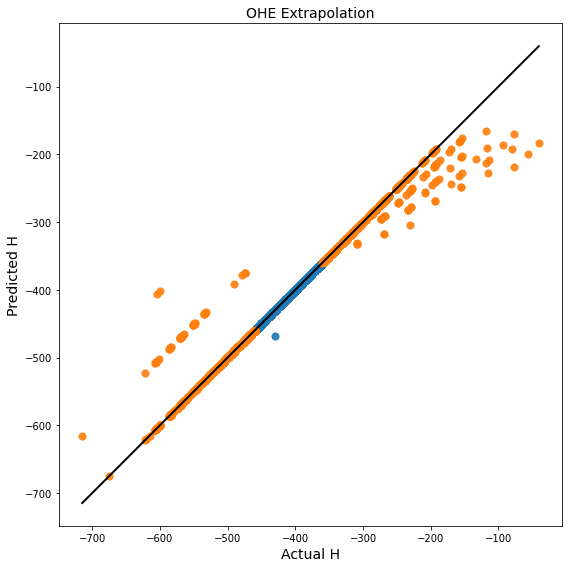

Test R² = 0.9914
Test MSE = 49.8051


In [5]:
###########################################################
# OHE-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
y = data["H"].values

# ===============================
# ONE-HOT ENCODING OF SMILES
# ===============================

# Character vocabulary
all_chars = sorted(set(''.join(smiles)))
char_to_int = {c:i for i,c in enumerate(all_chars)}

max_len = max(len(sm) for sm in smiles)
n_chars = len(all_chars)

print("Maximum SMILES length:", max_len)
print("Number of unique characters:", n_chars)

# Convert SMILES to OHE vectors
X = np.zeros((len(smiles), max_len * n_chars), dtype=np.uint8)

for i, sm in enumerate(smiles):
    for j, ch in enumerate(sm):
        X[i, j*n_chars + char_to_int[ch]] = 1

print("OHE Matrix Shape:", X.shape)

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Training range:", y_train.min(), "to", y_train.max())
print("Testing range:", y_test.min(), "to", y_test.max())

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ===============================
# USE ONLY 100% OF TRAINING DATA
# ===============================

sub_size = int(1.00 * len(X_train))

X_train_sub = X_train[:sub_size]
y_train_sub = y_train[:sub_size]

print("Training points used:", len(X_train_sub))

# ===============================
# SCALE FEATURES
# ===============================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_sub)
X_test_scaled = x_scaler.transform(X_test)

# ===============================
# RIDGE REGRESSION
# ===============================

ridge = Ridge(alpha=10e-4)

ridge.fit(X_train_scaled, y_train_sub)

# Predictions
y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)
# Residuals
errors = np.abs(y_train_sub - y_pred_train)

# Indices of the 10 largest errors
top10_idx = np.argsort(errors)[-10:]

print("Two most deviated molecules:\n")

for idx in top10_idx:
    print("SMILES           :", smiles[train_mask][:sub_size][idx])
    print("Actual H         :", y_train_sub[idx])
    print("Predicted H      :", y_pred_train[idx])
    print("Absolute Error   :", errors[idx])
    print("-"*50)

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train_sub, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train_sub, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)
print(f"Train MSE : {mse_train:.4f}")
print(f"Train R²  : {r2_train:.4f}")
print(f"Train RMSE : {rmse_train:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")

#===================================
#PARITY PLOT
#==================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_train_sub,
    y_pred_train,
    s=50,
    alpha=0.9
)

plt.scatter(
    y_test,
    y_pred_test,
    s=50,
    alpha=0.9
)

min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual H', fontsize=14)
plt.ylabel('Predicted H', fontsize=14)

plt.title('OHE Extrapolation', fontsize=14)

plt.tight_layout()

plt.savefig("OHE_Parity(-460_-360).png",
            dpi=600,
            bbox_inches='tight')

plt.show()

# Print test metrics
print(f"Test R² = {r2_test:.4f}")
print(f"Test MSE = {mse_test:.4f}")
vmin = min(y_train_sub.min(), y_test.min())
vmax = max(y_train_sub.max(), y_test.max())

plt.show()

In [ ]:
##########################################################
# CHEMCAL DESCRIPTOR-RIDGE REGRESSION(WITHOUT FEATURE SELECTION)
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import Descriptors

print("Total RDKIT descriptors:", len(Descriptors.descList))

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"]
y = data["H"].values

# ===============================
# chemical descriptor(no feature selection)
# ===============================
descriptor_values = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        values = [func(mol) for name,func in Descriptors.descList]
    else:
        values = [np.nan]*len(descriptor_name)
    
    descriptor_values.append(values)
    
X_df = pd.DataFrame(descriptor_values, columns=descriptor_names)
print("success")

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Training range:", y_train.min(), "to", y_train.max())
print("Testing range:", y_test.min(), "to", y_test.max())

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ===============================
# USE ONLY 100% OF TRAINING DATA
# ===============================

X_train_sub = X_train
y_train_sub = y_train

print("Training points used:", len(X_train_sub))

# ===============================
# SCALE FEATURES
# ===============================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_sub)
X_test_scaled = x_scaler.transform(X_test)

# ===============================
# RIDGE REGRESSION
# ===============================

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train_sub)

# Predictions
y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)
# Residuals
errors = np.abs(y_train_sub - y_pred_train)

# Indices of the 10 largest errors
#top10_idx = np.argsort(errors)[-10:]

#print("Two most deviated molecules:\n")

#for idx in top10_idx:
    #print("SMILES           :", smiles[train_mask][:sub_size][idx])
    #("Actual H         :", y_train_sub[idx])
    #print("Predicted H      :", y_pred_train[idx])
    #("Absolute Error   :", errors[idx])
    #print("-"*50)

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train_sub, y_pred_train)
r2_train = r2_score(y_train_sub, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)
print(f"Train MSE : {mse_train:.4f}")
print(f"Train R²  : {r2_train:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")

#===================================
#PARITY PLOT
#==================================

plt.figure(figsize=(6,8))

scatter = plt.scatter(
    y_train_sub,
    y_pred_train,
    c=y_train_sub,          # Color by actual enthalpy
    cmap='plasma',
    s=20,
    alpha=0.9
)

min_val = min(y_train_sub.min(), y_pred_train.min())
max_val = max(y_train_sub.max(), y_pred_train.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)

plt.title('Extrapolation - Train', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()
plt.figure(figsize=(6,8))

scatter = plt.scatter(y_test, y_pred_test, c=y_test, cmap='plasma', s=20, alpha=0.9)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)

plt.title('Extrapolation - Test', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()

#plt.savefig("OHE_Test_Parity(-550_-250).png",
            #dpi=600,
            #bbox_inches='tight')

plt.show()

# Print test metrics
print(f"Test R² = {r2_test:.4f}")
print(f"Test MSE = {mse_test:.4f}")
vmin = min(y_train_sub.min(), y_test.min())
vmax = max(y_train_sub.max(), y_test.max())

#plt.savefig("OHE_Train_Parity(-550_-250).png",
            #dpi=600,
            #bbox_inches='tight')

plt.show()

Total RDKIT descriptors: 209


Started
(133885, 2048)
int64
success
Training range: -459.185274 to -360.000294
Testing range: -714.559209 to -40.475117
Training samples: 109016
Testing samples: 24869
Training points used: 109016
Two most deviated molecules:

SMILES           : FC(F)(F)CC#C
Actual H         : -453.646706
Predicted H      : -365.4947759708437
Absolute Error   : 88.15193002915629
--------------------------------------------------
SMILES           : CCC(F)(F)F
Actual H         : -416.807775
Predicted H      : -328.44254657020866
Absolute Error   : 88.36522842979133
--------------------------------------------------
SMILES           : FC(F)(F)C#N
Actual H         : -430.442038
Predicted H      : -341.7047014967582
Absolute Error   : 88.7373365032418
--------------------------------------------------
SMILES           : NCC(F)(F)F
Actual H         : -432.845881
Predicted H      : -343.15234063874766
Absolute Error   : 89.69354036125236
--------------------------------------------------
SMILES           : O

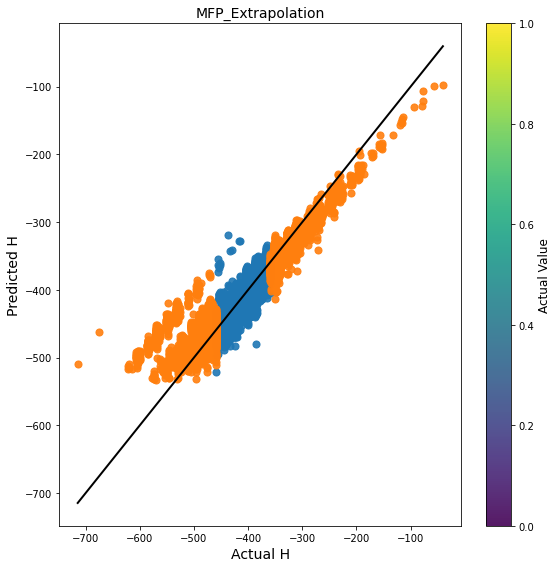

Test R² = 0.9411
Test MSE = 341.2443


In [10]:
##########################################################
# MORGANFINGERPRINT-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
H = data["H"]

print("Started")

# ===============================
# MORGAN FINGERPRINT OF SMILES
# ===============================

def smiles_to_count_fingerprint(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros((2048,), dtype=int)
    
    fp = AllChem.GetHashedMorganFingerprint(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,),dtype=int)
    for idx,count in fp.GetNonzeroElements().items():
        arr[idx] = count
    return arr

#Fingerprint Conversion
X = np.array([smiles_to_count_fingerprint(sm) for sm in smiles])
y = H.values

print(X.shape)
print(X.dtype)
print("success")

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Training range:", y_train.min(), "to", y_train.max())
print("Testing range:", y_test.min(), "to", y_test.max())

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ===============================
# USE ONLY 100% OF TRAINING DATA
# ===============================
sub_size = int(1.00 * len(X_train))
X_train_sub = X_train
y_train_sub = y_train

print("Training points used:", len(X_train_sub))

# ===============================
# SCALE FEATURES
# ===============================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_sub)
X_test_scaled = x_scaler.transform(X_test)

# ===============================
# RIDGE REGRESSION
# ===============================

ridge = Ridge(alpha=10e-4)

ridge.fit(X_train_scaled, y_train_sub)

# Predictions
y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)
# Residuals
errors = np.abs(y_train_sub - y_pred_train)

# Indices of the 10 largest errors
top10_idx = np.argsort(errors)[-10:]

print("Two most deviated molecules:\n")

for idx in top10_idx:
    print("SMILES           :", smiles[train_mask][:sub_size][idx])
    print("Actual H         :", y_train_sub[idx])
    print("Predicted H      :", y_pred_train[idx])
    print("Absolute Error   :", errors[idx])
    print("-"*50)

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train_sub, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train_sub, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)
print(f"Train MSE : {mse_train:.4f}")
print(f"Train R²  : {r2_train:.4f}")
print(f"Train RMSE : {rmse_train:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")

#===================================
#PARITY PLOT
#==================================

plt.figure(figsize=(8,8))

scatter = plt.scatter(
    y_train_sub,
    y_pred_train,
    s=50,
    alpha=0.9
)

plt.scatter(y_test, y_pred_test, s=50, alpha=0.9)

min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual H', fontsize=14)
plt.ylabel('Predicted H', fontsize=14)

plt.title('MFP_Extrapolation', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()

plt.savefig("MFP_(COUNTFINGER)_Parity(-460_-360).png",
            dpi=600,
            bbox_inches='tight')

plt.show()

# Print test metrics
print(f"Test R² = {r2_test:.4f}")
print(f"Test MSE = {mse_test:.4f}")
vmin = min(y_train_sub.min(), y_test.min())
vmax = max(y_train_sub.max(), y_test.max())


plt.show()

started
Index(['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumHeteroatoms'], dtype='object')
Total descriptors used:           MolWt  HeavyAtomMolWt  ExactMolWt  NumHeteroatoms
0        16.043          12.011   16.031300               0
1        17.031          14.007   17.026549               1
2        18.015          15.999   18.010565               1
3        26.038          24.022   26.015650               0
4        27.026          26.018   27.010899               1
...         ...             ...         ...             ...
133880  121.139         114.083  121.052764               2
133881  121.139         114.083  121.052764               2
133882  120.155         112.091  120.068748               2
133883  119.167         110.095  119.073499               1
133884  121.139         114.083  121.052764               2

[133885 rows x 4 columns]
Training range: -459.185274 to -360.000294
Testing range: -714.559209 to -40.475117
Training samples: 109016
Testing samples: 24869
Traini

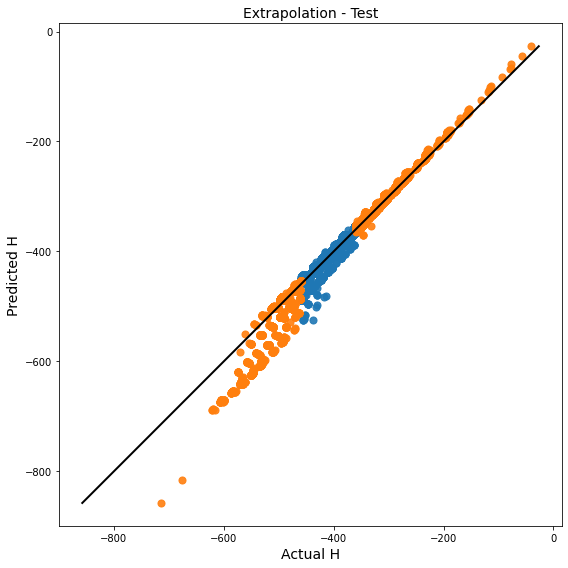

Test R² = 0.9726
Test MSE = 158.6318


In [14]:
##########################################################
# CHEMCAL DESCRIPTOR-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
X_df = pd.read_csv("selected_descriptors.csv")
X_df = X_df.drop(columns=["SMILES"])

print("started")

#==========================================
#CHEMICAL DESCRIPTOR WITH SELECTED FEATURES
#==========================================
y = data["H"].values

print(X_df.columns)
print("Total descriptors used:",X_df)
# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train = X_df[train_mask]
y_train = y[train_mask]

X_test = X_df[test_mask]
y_test = y[test_mask]

print("Training range:", y_train.min(), "to", y_train.max())
print("Testing range:", y_test.min(), "to", y_test.max())

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ===============================
# USE ONLY 100% OF TRAINING DATA
# ===============================
sub_size = int(1.00 * len(X_train))

X_train_sub = X_train
y_train_sub = y_train

print("Training points used:", len(X_train_sub))

# ===============================
# SCALE FEATURES
# ===============================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_sub)
X_test_scaled = x_scaler.transform(X_test)

# ===============================
# RIDGE REGRESSION
# ===============================

ridge = Ridge(alpha=10e-4)

ridge.fit(X_train_scaled, y_train_sub)

# Predictions
y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)
# Residuals
errors = np.abs(y_train_sub - y_pred_train)

# Indices of the 10 largest errors
top10_idx = np.argsort(errors)[-10:]

print("Two most deviated molecules:\n")

for idx in top10_idx:
    print("SMILES           :", smiles[train_mask][:sub_size].iloc[idx])
    print("Actual H         :", y_train_sub[idx])
    print("Predicted H      :", y_pred_train[idx])
    print("Absolute Error   :", errors[idx])
    print("-"*50)

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train_sub, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train_sub, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)
print(f"Train MSE : {mse_train:.4f}")
print(f"Train R²  : {r2_train:.4f}")
print(f"Train RMSE : {rmse_train:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")
#===================================
#PARITY PLOT
#==================================

plt.figure(figsize=(8,8))

scatter = plt.scatter(
    y_train_sub,
    y_pred_train,
    s=50,
    alpha=0.9
)

plt.scatter(y_test, y_pred_test, s=50, alpha=0.9)

min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual H', fontsize=14)
plt.ylabel('Predicted H', fontsize=14)

plt.title('Extrapolation - Test', fontsize=14)

plt.tight_layout()

plt.savefig("CD_RR_Parity(FS)_-460_-360.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

# Print test metrics
print(f"Test R² = {r2_test:.4f}")
print(f"Test MSE = {mse_test:.4f}")
vmin = min(y_train_sub.min(), y_test.min())
vmax = max(y_train_sub.max(), y_test.max())

plt.show()